In [15]:
import gc
import torch

# 清理之前可能存在的残留显存占用
gc.collect()
torch.cuda.empty_cache()

# 启用 PyTorch 显存管理优化
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, HeteroConv, MessagePassing
from torch_geometric.utils import negative_sampling
import torch_geometric.transforms as T
from torch_geometric.datasets import Yelp
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

import scipy.io as sio
from torch_geometric.data import HeteroData

def load_local_yelpchi(path='data/YelpChi/raw/YelpChi.mat'):
    # 1. 加载 mat 文件
    mat = sio.loadmat(path)
    
    # 2. 提取数据
    # x: 节点特征, y: 标签, net_rur/rtr/rsr: 邻接矩阵
    features = torch.FloatTensor(mat['features'].todense())
    labels = torch.LongTensor(mat['label'].flatten())
    
    # 定义异质图对象
    data = HeteroData()
    
    # 3. 添加节点（核心节点类型为 'review'）
    data['review'].x = features
    data['review'].y = labels
    
    # 4. 添加异质关系 (YelpChi 包含三种关系)
    # RUR: Review-User-Review, RTR: Review-Tax-Review, RSR: Review-Star-Review
    # 这里将 .mat 中的稀疏矩阵转为 edge_index
    for rel_name in ['net_rur', 'net_rtr', 'net_rsr']:
        adj = mat[rel_name].tocoo()
        row = torch.from_numpy(adj.row).to(torch.long)
        col = torch.from_numpy(adj.col).to(torch.long)
        edge_index = torch.stack([row, col], dim=0)
        
        # 命名格式: (源节点, 关系名, 目标节点)
        data['review', rel_name, 'review'].edge_index = edge_index
        
    return data


In [17]:
# YelpChi 数据集

# ==========================================
# 【模块一】：Config 参数
# ==========================================
class Config:
    hidden_dim = 16      
    proj_dim = 128       
    hops = 2             
    epochs = 500         
    soft_end = 200       # soft 轮数
    lr_init = 0.001
    target_sparsity = 0.30  # 诈骗检测需要更高的稀疏度（去噪）
    lambda_max = 5.0        # 强化稀疏性约束
    weight_decay = 1e-4
    link_weight = 0.7  # 链路预测损失权重

# ==========================================
# 【模块二】：关系感知采样器 (Relation-Aware)
# ==========================================
class RelationAwareBilinearSampler(nn.Module):
    def __init__(self, rel_types, in_dim, proj_dim=128):
        super().__init__()
        # 为每种关系定义独立的投影和双线性矩阵
        self.rel_keys = ['__'.join(rel) for rel in rel_types]
        self.projs = nn.ModuleDict({
            k: nn.Linear(in_dim, proj_dim) for k in self.rel_keys
        })
        self.rel_W = nn.ParameterDict({
            k: nn.Parameter(torch.Tensor(proj_dim, proj_dim)) for k in self.rel_keys
        })
        for p in self.rel_W.values():
            nn.init.xavier_uniform_(p)

    def forward(self, h_i, h_j, rel_type):
        rel_key = '__'.join(rel_type)
        z_i = self.projs[rel_key](h_i)
        z_j = self.projs[rel_key](h_j)
        W_r = self.rel_W[rel_key]
        score = torch.sum((z_i @ W_r) * z_j, dim=-1)
        return torch.sigmoid(score)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ==========================================
# 【模块三】：异质递归系统 (HeteroConv + Recursive Sampling)
# ==========================================
class HeteroNeuralRecursiveSystem(nn.Module):
    def __init__(self, metadata, in_side_dict, hidden_size, out_size, hops=2, tau=0.8):
        super().__init__()
        self.node_types, self.edge_types = metadata
        self.hops = hops
        self.tau = tau

        # [阶段一：语义发现] - 异质 GAT 架构
        self.input_projs = nn.ModuleDict({
            ntype: nn.Linear(in_side_dict[ntype], hidden_size * 8) 
            for ntype in self.node_types
        })
        self.convs = nn.ModuleList([
            HeteroConv({rel: GATConv(hidden_size * 8, hidden_size, heads=8, add_self_loops=False)
                        for rel in self.edge_types}, aggr='sum') for _ in range(2)
        ])
        self.lns = nn.ModuleList([
            nn.ModuleDict({nt: nn.LayerNorm(hidden_size * 8) for nt in self.node_types}) 
            for _ in range(2)
        ])

        # [阶段二：可学习采样器]
        self.sampler_net = RelationAwareBilinearSampler(self.edge_types, hidden_size * 8)

        # [※]：用于实现子图增强的反馈层
        self.subgraph_enhancer = HeteroConv({
            rel: SubgraphEnhancer(hidden_size * 8, hidden_size * 8)
            for rel in self.edge_types
        }, aggr='sum')

        # [阶段三：双线性链路预测器]
        self.rel_link_W = nn.ParameterDict({
            '__'.join(rel): nn.Parameter(torch.Tensor(hidden_size * 8, hidden_size * 8)) 
            for rel in self.edge_types if 'review' in rel
        })
        for p in self.rel_link_W.values():
            nn.init.xavier_uniform_(p)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 8, 64),
            nn.ReLU(),
            nn.Linear(64, out_size)
        )

    def get_sampling_weights(self, h_dict, edge_index_dict, start_mask_dict, hard):
        weights_dict = {rel: torch.zeros(edge_index_dict[rel].size(1), device=device) for rel in self.edge_types}
        active_nodes = {nt: mask.float() for nt, mask in start_mask_dict.items()}

        for _ in range(self.hops):
            new_active = {nt: torch.zeros_like(active_nodes[nt]) for nt in self.node_types}
            for rel in self.edge_types:
                src, _, dst = rel
                row, col = edge_index_dict[rel]
                scores = self.sampler_net(h_dict[src][row], h_dict[dst][col], rel)
                
                logits = torch.stack([1 - scores, scores], dim=-1).clamp(min=1e-9).log()
                mask = F.gumbel_softmax(logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
                
                curr_w = mask * active_nodes[src][row]
                weights_dict[rel] = torch.max(weights_dict[rel], curr_w)
                new_active[dst].scatter_add_(0, col, curr_w)
            
            active_nodes = {nt: (new_active[nt] > 1e-5).float() for nt in self.node_types}
        return weights_dict

    def forward(self, x_dict, edge_index_dict, start_mask_dict, hard=True):
        # 1. 语义发现 (初始 GAT 聚合)
        h_dict = {nt: F.elu(self.input_projs[nt](x)) for nt, x in x_dict.items()}
        for i in range(2):
            h_new = self.convs[i](h_dict, edge_index_dict)
            h_dict = {nt: F.elu(self.lns[i][nt](h_new[nt]) + h_dict[nt]) for nt in self.node_types}

        # 2. 采样阶段 (计算 weights_dict)
        weights_dict = self.get_sampling_weights(h_dict, edge_index_dict, start_mask_dict, hard)
        
        # 3. [实现基于采样子图的增强]：
        h_dict_enhanced = self.subgraph_enhancer(h_dict, edge_index_dict, weights_dict)
        
        # 残差连接：结合全局语义与采样后的精炼语义
        h_dict_enhanced = {nt: F.elu(h_dict_enhanced[nt] + h_dict[nt]) for nt in self.node_types}

        # 4. 下游分类 (基于增强后的特征)
        logits = self.classifier(h_dict_enhanced['review'])
        
        return F.log_softmax(logits, dim=1), weights_dict, h_dict_enhanced


# ==========================================
# 异质子图增强器 (Subgraph Enhancer)
# ==========================================
from torch_geometric.utils import softmax

class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        # 保持 add 聚合，因为权重已经通过 softmax 归一化了
        super().__init__(aggr='add') 
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, edge_weight):
        # 1. 节点特征投影
        x = self.lin(x)
        
        # 2. 局部竞争归一化 
        # softmax 会根据 edge_index[1]（目标节点）对 edge_weight 进行归一化
        # 这确保了每个 review 节点接收到的邻居总权重贡献之和为 1 , 这样即使有 241 个邻居，也不会出现数值爆炸和特征稀释
        norm_weight = softmax(edge_weight, edge_index[1], num_nodes=x.size(0))
        
        return self.propagate(edge_index, x=x, edge_weight=norm_weight)

    def message(self, x_j, edge_weight):
        # 归一化后的权重直接参与特征加权
        return edge_weight.view(-1, 1) * x_j

# ==========================================
# 模块四：数据加载 (YelpChi 异质图)
# ==========================================
from torch_geometric.datasets import Yelp
from sklearn.metrics import roc_auc_score, f1_score

dataset_name = 'YelpChi'
# 加载 Yelp 数据集
data = load_local_yelpchi().to(device)

# 1. 处理特征维度不一致：获取每种节点类型的输入维度
# YelpChi 通常包含 review, user, business 等节点
in_size_dict = {ntype: data[ntype].x.size(1) for ntype in data.node_types}

# 2. 划分数据集 
num_reviews = data['review'].num_nodes
indices = torch.randperm(num_reviews)
train_size = int(0.4 * num_reviews)
val_size = int(0.2 * num_reviews)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

# 3. 构造 target_mask_dict (用于递归采样起点)
# 在诈骗检测中，我们主要对 'review' 节点进行分类
train_mask_dict = {nt: torch.zeros(data[nt].num_nodes, dtype=torch.bool) for nt in data.node_types}
train_mask_dict['review'][train_idx] = True

data = data.to(device)
# 将 mask 转到设备
train_mask_dict = {k: v.to(device) for k, v in train_mask_dict.items()}

# 初始化异质模型
model = HeteroNeuralRecursiveSystem(
    metadata=data.metadata(),
    in_side_dict=in_size_dict,
    hidden_size=Config.hidden_dim,
    out_size=2, # 诈骗 vs 正常
    hops=Config.hops
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=Config.lr_init, weight_decay=Config.weight_decay)

# =============================================================
# 类别权重重赋值
# =============================================================
labels = data['review'].y[train_idx]
count_neg = (labels == 0).sum().item()
count_pos = (labels == 1).sum().item()

# 放大因子 alpha (取值 1.2 到 2.0 之间)
# alpha 越大，模型越不敢漏掉诈骗者，但可能会增加误判（FP）
alpha = 1.5 

# 给诈骗类额外的关注
pos_weight = (count_neg / count_pos) * alpha

weight_val = torch.tensor([1.0, pos_weight]).to(device)

print(f"数据分布统计 - 正常(0): {count_neg}, 诈骗(1): {count_pos}")
print(f"强化因子 alpha: {alpha}")
print(f"最终 Loss 加权系数 (正常 vs 诈骗): [1.0, {pos_weight:.2f}]")


# ==========================================
# 模块五：训练逻辑 
# ==========================================
# 统一导入旧版兼容接口
from torch.cuda.amp import autocast, GradScaler 
from sklearn.metrics import confusion_matrix, classification_report

# 初始化缩放器：移除 device_type 以修复 TypeError
scaler = GradScaler() 

def evaluate_with_best_threshold(val_indices, test_indices):
    model.eval()
    with torch.no_grad():
        with autocast():
            # 接收 3 个返回值防止模型层面的 ValueError
            logits, _, _ = model(data.x_dict, data.edge_index_dict, 
                                 {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}, 
                                 hard=True)
        
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        y_true = data['review'].y.cpu().numpy()

        # --- 第一步：在验证集上搜索最佳阈值 ---
        val_y = y_true[val_indices]
        val_probs = probs[val_indices]
        
        best_threshold = 0.5
        max_val_f1 = 0
        
        # 遍历候选阈值找到使验证集 F1 最高的点
        for threshold in np.linspace(0.1, 0.9, 81): 
            current_f1 = f1_score(val_y, val_probs > threshold, average='macro')
            if current_f1 > max_val_f1:
                max_val_f1 = current_f1
                best_threshold = threshold
        
        # --- 第二步：将找到的最佳阈值应用到测试集进行最终评估 ---
        test_y = y_true[test_indices]
        test_probs = probs[test_indices]
        test_pred = (test_probs > best_threshold).astype(int)
        
        test_auc = roc_auc_score(test_y, test_probs)
        test_f1 = f1_score(test_y, test_pred, average='macro')
        test_cm = confusion_matrix(test_y, test_pred)
        
        # --- 打印结果 (合并混淆矩阵) ---
        tn, fp, fn, tp = test_cm.ravel()
        print(f"\n" + "="*40)
        print(f"[验证集搜索结果] 最佳阈值: {best_threshold:.3f} | 验证集 F1: {max_val_f1:.4f}")
        print(f"[测试集最终结果] AUC: {test_auc:.4f} | F1: {test_f1:.4f}")
        print(f"测试集混淆矩阵: TN:{tn:5d}, FP:{fp:5d}, FN:{fn:5d}, TP:{tp:5d}")
        print("-" * 40)
        print(classification_report(test_y, test_pred, target_names=['Normal', 'Fraud'], zero_division=0))
        
        return test_auc, test_f1, best_threshold, max_val_f1

def evaluate_fraud(split_indices):
    model.eval()
    with torch.no_grad():
        full_masks = {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}

        with autocast():
            # 接收 3 个返回值防止 ValueError
            logits, _, _ = model(data.x_dict, data.edge_index_dict, full_masks, hard=True)
        
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        y_true = data['review'].y.cpu().numpy()
        
        auc = roc_auc_score(y_true[split_indices], probs[split_indices])
        f1 = f1_score(y_true[split_indices], probs[split_indices] > 0.75, average='macro')
        
        return auc, f1


import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score


def train(epoch, total_epochs, start_tau, end_tau):
    model.train()
    
    # 1. 参数调度
    use_hard = True if epoch > Config.soft_end else False
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau
    
    curr_lambda = 0.1
    if epoch > (Config.soft_end / 3):
        if epoch <= Config.soft_end:
            progress = (epoch - Config.soft_end / 3) / (Config.soft_end * 2 / 3)
            curr_lambda = 0.1 + progress * (Config.lambda_max - 0.1)
        else:
            curr_lambda = Config.lambda_max

    optimizer.zero_grad()

    # 2. 混合精度前向传播 (兼容版)
    with autocast():
        log_probs, weights_dict, h_dict_enhanced = model(
            data.x_dict, data.edge_index_dict, train_mask_dict, hard=use_hard
        )
        loss_clf = F.nll_loss(log_probs[train_idx], data['review'].y[train_idx], weight=weight_val)
        
        loss_link = 0
        relevant_rels = [rel for rel in data.edge_types if 'review' in rel]
        max_link_edges = 10000 
        for rel in relevant_rels:
            rel_key = '__'.join(rel)
            src_nt, _, dst_nt = rel
            full_edge_index = data.edge_index_dict[rel]
            perm = torch.randperm(full_edge_index.size(1), device=device)[:max_link_edges]
            edge_index = full_edge_index[:, perm]
            neg_edge_index = negative_sampling(edge_index, num_nodes=(data[src_nt].num_nodes, data[dst_nt].num_nodes)).to(device)
            
            h_src, h_dst = h_dict_enhanced[src_nt], h_dict_enhanced[dst_nt]
            W_link = model.rel_link_W[rel_key]
            
            pos_logits = torch.sum((h_src[edge_index[0]] @ W_link) * h_dst[edge_index[1]], dim=-1)
            neg_logits = torch.sum((h_src[neg_edge_index[0]] @ W_link) * h_dst[neg_edge_index[1]], dim=-1)
            loss_link += F.binary_cross_entropy_with_logits(pos_logits, torch.ones_like(pos_logits)) + \
                        F.binary_cross_entropy_with_logits(neg_logits, torch.zeros_like(neg_logits))
        
        loss_link = loss_link / len(relevant_rels) if relevant_rels else 0
        all_ws = torch.cat([w for w in weights_dict.values()])
        current_sp = all_ws.mean()
        loss_sparse = F.mse_loss(current_sp, torch.tensor(Config.target_sparsity, device=device))
        
        total_loss = loss_clf + (Config.link_weight * loss_link) + (curr_lambda * loss_sparse)
        if current_sp < 0.05: total_loss += (0.1 - current_sp) * 20

    # 3. 反向传播
    scaler.scale(total_loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()
    torch.cuda.empty_cache()
    
    return total_loss.item(), loss_clf.item(), loss_link.item(), loss_sparse.item(), (all_ws > 0.5).float().mean().item(), curr_lambda

# ==========================================
# 执行训练循环 
# ==========================================

history = {
    'train_loss': [], 'clf_loss': [], 'link_loss': [], 
    'sparse_loss': [], 'sparsity': [], 'valid_F1': [], 'test_F1': []
}
best_valid_f1 = 0.0

for epoch in range(1, Config.epochs + 1):
    # --- 训练阶段 ---
    t_loss, c_loss, l_loss, s_loss, sp_rate, c_lam = train(epoch, Config.epochs, 1.0, 0.1)
    
    # 记录每一个 Epoch 的训练状态
    history['train_loss'].append(t_loss)
    history['clf_loss'].append(c_loss)
    history['link_loss'].append(l_loss)
    history['sparse_loss'].append(s_loss)
    history['sparsity'].append(sp_rate)
    
    # --- 评估阶段 ---
    if epoch % 10 == 0:
        if epoch % 100 == 0:
            # 获取当前 Epoch 搜索出的最佳验证集 F1 和对应的测试集指标
            test_auc, test_f1, best_t, val_f1 = evaluate_with_best_threshold(val_idx, test_idx)
        else:
            # 基础评估（非 100 轮时）
            val_auc, val_f1 = evaluate_fraud(val_idx)
            test_auc, test_f1 = evaluate_fraud(test_idx)
            best_t = 0.5 # 记录一个默认值防止 print 报错
        
        # 记录当前的 F1 指标
        history['valid_F1'].append(val_f1) 
        history['test_F1'].append(test_f1)

        # 保存最佳模型 (现在 val_f1 绝对是当前轮次的最新值)
        if val_f1 > best_valid_f1:
            best_valid_f1 = val_f1
            torch.save(model.state_dict(), 'best_hetero_model.pt')
            # 修正打印逻辑，确保 best_t 在所有分支都有定义
            t_str = f"{best_t:.2f}" if epoch % 100 == 0 else "0.50"
            print(f"[*] Saved Best Model @ Ep {epoch} | Val F1: {val_f1:.4f} | Threshold: {t_str}")

        # 打印实时日志
        print(f"Ep: {epoch:03d} | Loss: {t_loss:.4f} (Clf:{c_loss:.3f}, Link:{l_loss:.3f}) | "
              f"Sp: {sp_rate:.4f} | Val_F1: {val_f1:.4f} | Test_AUC: {test_auc:.4f}")

数据分布统计 - 正常(0): 15740, 诈骗(1): 2641
强化因子 alpha: 1.5
最终 Loss 加权系数 (正常 vs 诈骗): [1.0, 8.94]


/tmp/ipykernel_649007/1258439952.py:233: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_649007/1258439952.py:322: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_649007/1258439952.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_649007/1258439952.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[*] Saved Best Model @ Ep 10 | Val F1: 0.4605 | Threshold: 0.50
Ep: 010 | Loss: 7.1854 (Clf:0.600, Link:9.404) | Sp: 0.1544 | Val_F1: 0.4605 | Test_AUC: 0.6902


/tmp/ipykernel_649007/1258439952.py:322: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_649007/1258439952.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_649007/1258439952.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[*] Saved Best Model @ Ep 20 | Val F1: 0.6011 | Threshold: 0.50
Ep: 020 | Loss: 1.6661 (Clf:0.577, Link:1.553) | Sp: 0.1545 | Val_F1: 0.6011 | Test_AUC: 0.7251


...

Ep: 480 | Loss: 0.4174 (Clf:0.285, Link:0.189) | Sp: 0.3022 | Val_F1: 0.7556 | Test_AUC: 0.9038


/tmp/ipykernel_649007/1258439952.py:322: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_649007/1258439952.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_649007/1258439952.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep: 490 | Loss: 0.4175 (Clf:0.288, Link:0.185) | Sp: 0.2983 | Val_F1: 0.7464 | Test_AUC: 0.9003


/tmp/ipykernel_649007/1258439952.py:322: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_649007/1258439952.py:238: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



[验证集搜索结果] 最佳阈值: 0.770 | 验证集 F1: 0.7715
[测试集最终结果] AUC: 0.9082 | F1: 0.7744
测试集混淆矩阵: TN:14321, FP: 1373, FN:  859, TP: 1830
----------------------------------------
              precision    recall  f1-score   support

      Normal       0.94      0.91      0.93     15694
       Fraud       0.57      0.68      0.62      2689

    accuracy                           0.88     18383
   macro avg       0.76      0.80      0.77     18383
weighted avg       0.89      0.88      0.88     18383

[*] Saved Best Model @ Ep 500 | Val F1: 0.7715 | Threshold: 0.77
Ep: 500 | Loss: 0.4120 (Clf:0.278, Link:0.192) | Sp: 0.2968 | Val_F1: 0.7715 | Test_AUC: 0.9082


In [18]:
# 采样子图规模统计

def analyze_sampling_scale_full_comparison(threshold=0.5):
    model.eval()
    with torch.no_grad():
        # 获取全量决策权重
        full_masks = {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}
        _, weights_dict, _ = model(data.x_dict, data.edge_index_dict, full_masks, hard=True)

    def get_stats_for_split(name, indices):
        node_counts = []
        edge_counts = []
        
        for seed_idx in indices.tolist():
            subgraph_nodes = {('review', seed_idx)}
            subgraph_edges = 0
            
            # 模拟模型 2-hops 生长
            current_layer = {seed_idx}
            for hop in range(Config.hops):
                next_layer = set()
                for rel in data.edge_types:
                    if rel[0] == 'review':
                        edge_index = data.edge_index_dict[rel]
                        w = weights_dict[rel]
                        
                        # 查找采样成功的边
                        mask = torch.isin(edge_index[0], torch.tensor(list(current_layer), device=device))
                        sampled_mask = mask & (w > threshold)
                        
                        if sampled_mask.any():
                            subgraph_edges += sampled_mask.sum().item()
                            neighbors = edge_index[1][sampled_mask].cpu().tolist()
                            for n in neighbors:
                                subgraph_nodes.add(('review', n))
                                next_layer.add(n)
                current_layer = next_layer
            
            node_counts.append(len(subgraph_nodes))
            edge_counts.append(subgraph_edges)
            
        print(f"\n--- {name} 规模统计 ---")
        print(f"平均节点数: {np.mean(node_counts):.2f} | 最大节点数: {np.max(node_counts)}")
        print(f"平均边数: {np.mean(edge_counts):.2f} | 最大边数: {np.max(edge_counts)}")
        print(f"空子图（孤立点）比例: {(np.array(edge_counts)==0).mean():.1%}")
        return node_counts, edge_counts

    # 执行对比分析
    train_nodes, train_edges = get_stats_for_split("训练集", train_idx)
    test_nodes, test_edges = get_stats_for_split("测试集", test_idx)
    
    return (train_nodes, train_edges), (test_nodes, test_edges)


In [19]:
stats_train, stats_test = analyze_sampling_scale_full_comparison()


--- 训练集 规模统计 ---
平均节点数: 326.22 | 最大节点数: 797
平均边数: 4017.91 | 最大边数: 100906
空子图（孤立点）比例: 4.3%

--- 测试集 规模统计 ---
平均节点数: 327.59 | 最大节点数: 797
平均边数: 4117.90 | 最大边数: 103378
空子图（孤立点）比例: 4.2%


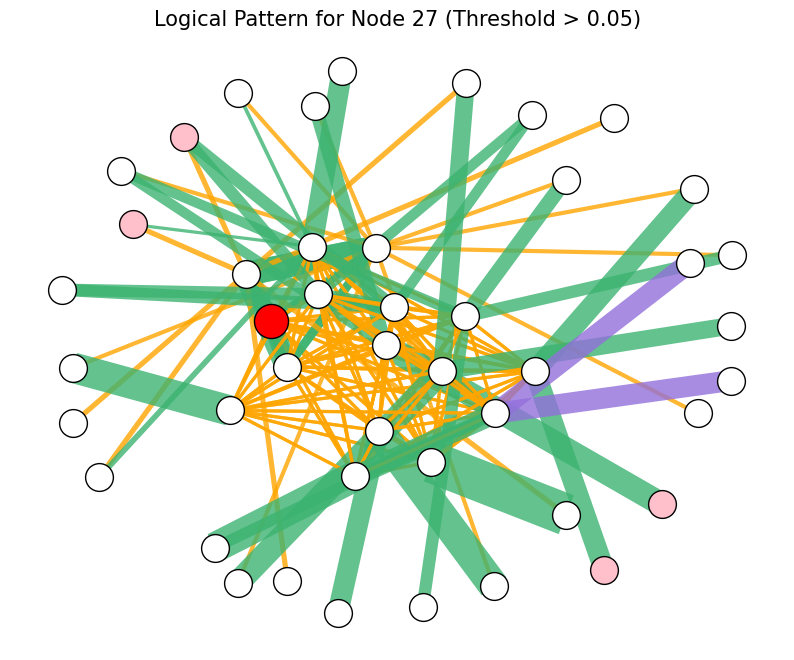

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_core_patterns(seed_idx, contribution_threshold=0.05):
    """
    contribution_threshold: 贡献度阈值 (0.05 表示该邻居贡献了超过 5% 的信息)
    """
    model.eval()
    with torch.no_grad():
        # 1. 模拟前向传播获取原始权重
        full_masks = {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}
        _, weights_dict, _ = model(data.x_dict, data.edge_index_dict, full_masks, hard=True)
        
        # 2. 计算局部归一化权重 (Logic Pruning)
        norm_weights_dict = {}
        for rel in data.edge_types:
            norm_weights_dict[rel] = softmax(weights_dict[rel], data.edge_index_dict[rel][1], 
                                            num_nodes=data['review'].x.size(0))

    # 3. 构建可视化图
    G_core = nx.MultiGraph()
    seed_node = ('review', seed_idx)
    rel_colors = {'net_rur': '#9370DB', 'net_rtr': '#3CB371', 'net_rsr': '#FFA500'}
    
    # 递归生长 2-hops
    nodes_to_visit = [seed_node]
    visited_nodes = {seed_node}
    
    for hop in range(2):
        next_layer = []
        for nt, idx in nodes_to_visit:
            for rel in data.edge_types:
                if rel[0] == nt: 
                    edge_index = data.edge_index_dict[rel]
                    mask = (edge_index[0] == idx) 
                    if not mask.any(): continue
                    
                    # 获取该节点发出的所有邻居及其对应的【归一化贡献度】
                    targets = edge_index[1][mask]
                    # 注意：归一化是基于目标节点计算的，所以这里取法要准确
                    scores = norm_weights_dict[rel][mask] 
                    
                    for v_idx, score in zip(targets, scores):
                        # 【核心过滤：只绘制逻辑上的显著节点】
                        if score.item() > contribution_threshold:
                            neighbor_node = (rel[2], v_idx.item())
                            G_core.add_edge((nt, idx), neighbor_node, 
                                           rel=rel[1], weight=score.item())
                            
                            if neighbor_node not in visited_nodes:
                                visited_nodes.add(neighbor_node)
                                next_layer.append(neighbor_node)
        nodes_to_visit = next_layer

    # 4. 绘图展示 (边的粗细代表逻辑贡献度)
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G_core, k=0.8, seed=42)
    
    for node in G_core.nodes():
        nt, idx = node
        label = data['review'].y[idx].item()
        color = 'red' if node == seed_node else ('pink' if label == 1 else 'white')
        nx.draw_networkx_nodes(G_core, pos, nodelist=[node], node_color=color, 
                               edgecolors='black', node_size=600 if node == seed_node else 400)
    
    for u, v, d in G_core.edges(data=True):
        # 边的宽度与归一化贡献度成正比
        nx.draw_networkx_edges(G_core, pos, edgelist=[(u, v)], 
                               edge_color=rel_colors.get(d['rel'], 'gray'), 
                               width=d['weight'] * 30, alpha=0.8)

    plt.title(f"Logical Pattern for Node {seed_idx} (Threshold > {contribution_threshold})" , fontsize=15)
    plt.axis('off')
    plt.show()

# 示例：查看某个诈骗节点的“逻辑骨干”
visualize_core_patterns(seed_idx=27, contribution_threshold=0.05)

In [37]:
# 在训练结束后运行,进行特定子图分析
def analyze_subgraph_patterns(threshold=0.5):
    model.eval()
    with torch.no_grad():
        # 1. 实时获取全量采样权重
        # 构造全 1 的 mask 作为推理起点
        full_masks = {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}
        # 适配你 forward 的 3 个返回值：logits, weights_dict, h_enhanced
        _, weights_dict, _ = model(data.x_dict, data.edge_index_dict, full_masks, hard=True)

    # 2. 定义并初始化 total_growth (你的代码里原本没有这个)
    num_reviews = data['review'].num_nodes
    total_growth = torch.zeros(num_reviews, device=device)

    # 3. 统计每个 review 节点作为源节点时保留的边总数
    for rel in data.edge_types:
        src, rel_name, dst = rel
        if src == 'review': # 只统计以评论为核心向外生长的情况
            edge_index = data.edge_index_dict[rel]
            w = weights_dict[rel]
            # 统计 Hard 模式下被保留的边 (w > 0.5)
            total_growth.scatter_add_(0, edge_index[0], (w > threshold).float())

    # 4. 针对测试集进行模式分类
    subgraph_sizes = total_growth[test_idx].cpu().numpy()
    labels = data['review'].y[test_idx].cpu().numpy()

    isolated = (subgraph_sizes == 0)
    small_patterns = (subgraph_sizes > 0) & (subgraph_sizes <= 3)
    complex_gangs = (subgraph_sizes > 3)

    print(f"--- 测试集子图模式统计 (N={len(test_idx)}) ---")
    print(f"1. 孤立节点 (被模型完全去噪): {isolated.sum()} ({isolated.sum()/len(test_idx):.1%})")
    print(f"2. 小型关联模式 (1-3条边): {small_patterns.sum()} ({small_patterns.sum()/len(test_idx):.1%})")
    print(f"3. 复杂诈骗团伙 (>3条边): {complex_gangs.sum()} ({complex_gangs.sum()/len(test_idx):.1%})")
    
    # 验证复杂团伙的准确性
    if complex_gangs.sum() > 0:
        fraud_in_gangs = labels[complex_gangs].sum()
        print(f"   -> 复杂团伙中的真实诈骗节点数: {fraud_in_gangs} (命中率: {fraud_in_gangs/complex_gangs.sum():.1%})")

    return total_growth, complex_gangs

# 运行统计
total_growth, complex_mask = analyze_subgraph_patterns()


def find_top_case_studies(total_growth, top_k=5):
    # 仅在测试集的真实诈骗节点中寻找
    fraud_test_mask = (data['review'].y[test_idx] == 1)
    test_growth_values = total_growth[test_idx]
    
    # 找到采样边数最多的 Top-K 节点
    top_values, top_indices = torch.topk(test_growth_values * fraud_test_mask.float(), top_k)
    
    print(f"\n--- 筛选出的 Top-{top_k} 典型诈骗团伙种子 ---")
    results = []
    for i in range(top_k):
        seed_id = test_idx[top_indices[i]].item()
        edge_count = top_values[i].item()
        print(f"Rank {i+1}: 节点 ID {seed_id} | 关联边数: {int(edge_count)}")
        results.append(seed_id)
        
    return results

top_seeds = find_top_case_studies(total_growth)

--- 测试集子图模式统计 (N=18383) ---
1. 孤立节点 (被模型完全去噪): 739 (4.0%)
2. 小型关联模式 (1-3条边): 688 (3.7%)
3. 复杂诈骗团伙 (>3条边): 16956 (92.2%)
   -> 复杂团伙中的真实诈骗节点数: 2520 (命中率: 14.9%)

--- 筛选出的 Top-5 典型诈骗团伙种子 ---
Rank 1: 节点 ID 40932 | 关联边数: 494
Rank 2: 节点 ID 40925 | 关联边数: 472
Rank 3: 节点 ID 40775 | 关联边数: 472
Rank 4: 节点 ID 40774 | 关联边数: 472
Rank 5: 节点 ID 40798 | 关联边数: 464


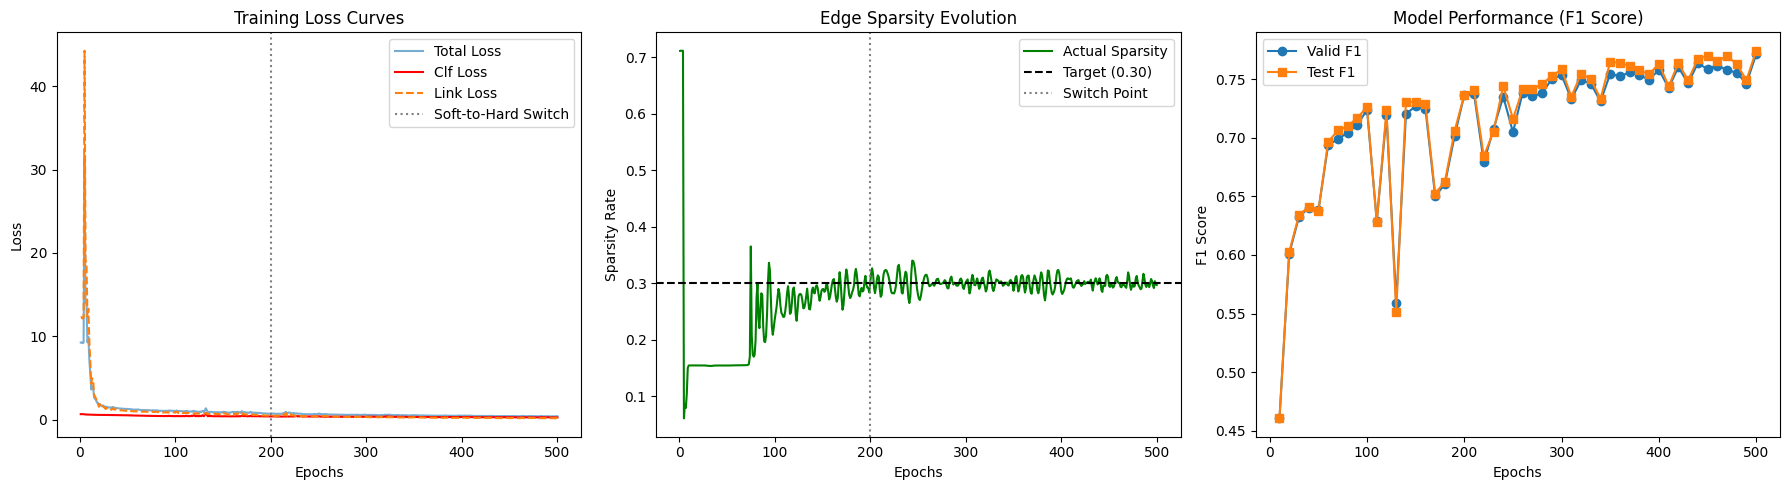

In [38]:
# 训练过程可视化

import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 图 1：各项 Loss 变化
    axes[0].plot(epochs, history['train_loss'], label='Total Loss', alpha=0.6)
    axes[0].plot(epochs, history['clf_loss'], label='Clf Loss', color='red')
    if 'link_loss' in history:
        axes[0].plot(epochs, history['link_loss'], label='Link Loss', linestyle='--')
    axes[0].axvline(x=200, color='gray', linestyle=':', label='Soft-to-Hard Switch')
    axes[0].set_title('Training Loss Curves')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # 图 2：稀疏度演变 (Sparsity)
    axes[1].plot(epochs, history['sparsity'], color='green', label='Actual Sparsity')
    axes[1].axhline(y=0.30, color='black', linestyle='--', label='Target (0.30)')
    axes[1].axvline(x=200, color='gray', linestyle=':', label='Switch Point')
    axes[1].set_title('Edge Sparsity Evolution')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Sparsity Rate')
    axes[1].legend()

    # 图 3：性能指标 (Valid F1 / Test F1)
    # 注意：history 中的评估指标是每 10 轮记录一次
    eval_epochs = [i*10 for i in range(1, len(history['valid_F1']) + 1)]
    axes[2].plot(eval_epochs, history['valid_F1'], marker='o', label='Valid F1')
    axes[2].plot(eval_epochs, history['test_F1'], marker='s', label='Test F1')
    axes[2].set_title('Model Performance (F1 Score)')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# 调用方式：
plot_training_history(history)

In [39]:
import sys
!{sys.executable} -m pip install seaborn

In [40]:
# 局部权重优化后 核心贡献子图

import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import softmax

def visualize_core_neighbor_contribution(seed_idx, top_k=8, significance_threshold=0.05):
    model.eval()
    with torch.no_grad():
        # 1. 获取全量权重
        full_masks = {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}
        _, weights_dict, _ = model(data.x_dict, data.edge_index_dict, full_masks, hard=True)
        
        # 2. 计算局部注意力标准化（Local Softmax）
        # 这是筛选“核心贡献”的关键逻辑：将权重转化为邻居间的竞争得分
        norm_weights_dict = {}
        for rel in data.edge_types:
            # 依据目标节点进行归一化，计算对该 Review 节点的贡献比例
            norm_weights_dict[rel] = softmax(weights_dict[rel], data.edge_index_dict[rel][1], 
                                            num_nodes=data['review'].x.size(0))

    # 3. 关系配色与配置
    rel_colors = {'net_rur': '#9370DB', 'net_rtr': '#3CB371', 'net_rsr': '#FFA500'}
    G_core = nx.MultiGraph()
    seed_node = ('review', seed_idx)
    
    # 4. 构建精炼子图：仅追踪核心贡献邻居
    nodes_to_visit = [seed_node]
    visited_nodes = {seed_node}
    
    # 递归生长 2 层
    for hop in range(2):
        next_layer = []
        for nt, idx in nodes_to_visit:
            for rel in data.edge_types:
                if rel[0] == nt: # 从当前节点出发
                    edge_index = data.edge_index_dict[rel]
                    # 获取该关系下所有指向当前节点的边及其归一化贡献
                    mask = (edge_index[1] == idx) 
                    if not mask.any(): continue
                    
                    # 提取贡献分
                    scores = norm_weights_dict[rel][mask]
                    neighbors = edge_index[0][mask]
                    
                    # --- 核心筛选逻辑 ---
                    # 同时满足：1. 贡献分进入前 K 名；2. 贡献分超过显著性阈值
                    current_k = min(top_k, scores.size(0))
                    top_val, top_idx = torch.topk(scores, current_k)
                    
                    for v_idx, score in zip(neighbors[top_idx], top_val):
                        if score.item() < significance_threshold: continue
                        
                        neighbor_node = (rel[2], v_idx.item())
                        # 添加核心边
                        G_core.add_edge(neighbor_node, (nt, idx), 
                                       rel=rel[1], 
                                       weight=score.item(), 
                                       label=f"{score.item():.2f}")
                        
                        if neighbor_node not in visited_nodes:
                            visited_nodes.add(neighbor_node)
                            next_layer.append(neighbor_node)
        nodes_to_visit = next_layer

    # 5. 绘图展示
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G_core, k=1.0, seed=42)
    
    # 绘制节点：红色为种子，粉色为诈骗邻居，白色为正常邻居
    for node in G_core.nodes():
        nt, idx = node
        label = data['review'].y[idx].item()
        color = 'red' if node == seed_node else ('pink' if label == 1 else 'white')
        nx.draw_networkx_nodes(G_core, pos, nodelist=[node], node_color=color, 
                               edgecolors='black', node_size=800 if node == seed_node else 500)
    
    # 绘制核心贡献边
    for u, v, d in G_core.edges(data=True):
        nx.draw_networkx_edges(G_core, pos, edgelist=[(u, v)], 
                               edge_color=rel_colors.get(d['rel'], 'gray'), 
                               width=d['weight'] * 20, alpha=0.9) # 粗细代表贡献度

    plt.title(f"Core Pattern for Node {seed_idx} (Local Softmax Filtered)", fontsize=15)
    plt.axis('off')
    plt.show()

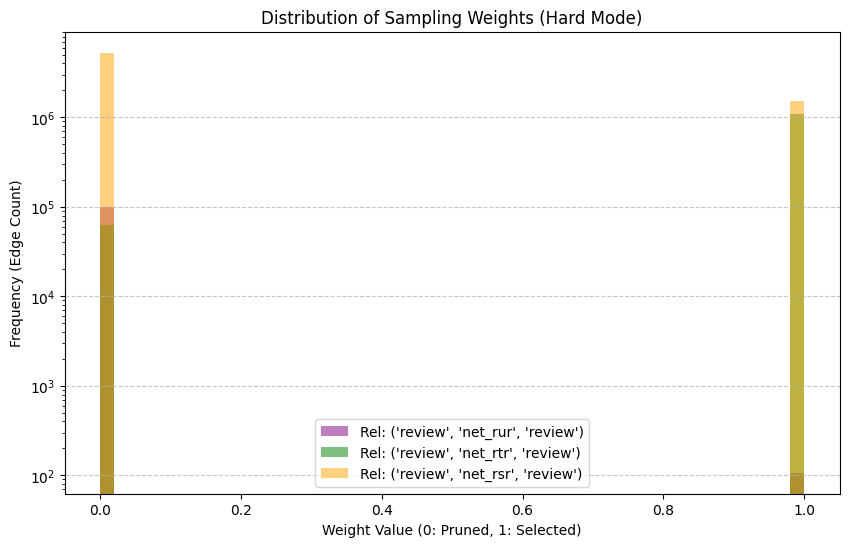

In [41]:
# 采样分布
import numpy as np

def plot_weight_distribution(model, data):
    model.eval()
    with torch.no_grad():
        # 获取最新的采样权重
        full_masks = {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}
        _, weights_dict, _ = model(data.x_dict, data.edge_index_dict, full_masks, hard=True)

    plt.figure(figsize=(10, 6))
    
    # 遍历每种关系绘制分布
    colors = ['purple', 'green', 'orange']
    for i, (rel_name, w) in enumerate(weights_dict.items()):
        weights_flat = w.cpu().numpy()
        # 绘制直方图
        plt.hist(weights_flat, bins=50, alpha=0.5, label=f'Rel: {rel_name}', color=colors[i % 3])

    plt.title('Distribution of Sampling Weights (Hard Mode)')
    plt.xlabel('Weight Value (0: Pruned, 1: Selected)')
    plt.ylabel('Frequency (Edge Count)')
    plt.yscale('log') # 因为 0 和 1 的数量通常极大，建议使用对数坐标
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# 调用方式：
plot_weight_distribution(model, data)

In [42]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_full_hetero_growth(seed_idx, threshold=0.5):
    model.eval()
    with torch.no_grad():
        # 1. 获取全量采样决策
        full_masks = {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}
        _, weights_dict, _ = model(data.x_dict, data.edge_index_dict, full_masks, hard=True)

    G = nx.MultiGraph() # 使用多重图以显示不同类型的边
    seed_node = ('review', seed_idx)
    
    # 定义不同关系的颜色
    rel_colors = {
        'net_rur': '#9370DB', # 紫色：同用户
        'net_rtr': '#3CB371', # 绿色：同时间
        'net_rsr': '#FFA500'  # 橙色：同评分
    }
    
    # 递归生长 2-hops
    nodes_to_visit = {seed_node}
    visited_nodes = set()
    
    for hop in range(2):
        current_layer = nodes_to_visit - visited_nodes
        if not current_layer: break
        for nt, idx in current_layer:
            visited_nodes.add((nt, idx))
            for rel in data.edge_types: # 遍历所有关系
                src, rel_name, dst = rel
                if src == nt:
                    edge_index = data.edge_index_dict[rel]
                    w = weights_dict[rel]
                    mask = (edge_index[0] == idx)
                    if mask.any():
                        for n_idx, weight in zip(edge_index[1][mask], w[mask]):
                            neighbor_node = (dst, n_idx.item())
                            is_sampled = weight.item() > threshold
                            # 记录边信息
                            G.add_edge((nt, idx), neighbor_node, 
                                       rel=rel_name, weight=weight.item(), sampled=is_sampled)
                            nodes_to_visit.add(neighbor_node)

    # --- 绘图 ---
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    
    # 绘制节点
    for node in G.nodes():
        nt, idx = node
        label = data['review'].y[idx].item()
        
        # 核心逻辑：被选中的节点圈红
  
        is_picked = any(d['sampled'] for _, _, d in G.edges(node, data=True)) or node == seed_node
        
        color = 'red' if node == seed_node else ('pink' if label == 1 else 'white')
        nx.draw_networkx_nodes(G, pos, nodelist=[node], 
                               node_color=color,
                               edgecolors='red' if is_picked else '#A9A9A9',
                               linewidths=3 if is_picked else 1,
                               node_size=700 if node == seed_node else 500)

    # 绘制边：按关系类型着色
    for u, v, key, d in G.edges(keys=True, data=True):
        color = rel_colors.get(d['rel'], 'gray')
        style = 'solid' if d['sampled'] else 'dashed'
        alpha = 0.8 if d['sampled'] else 0.1
        width = 2.5 if d['sampled'] else 1
        
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], 
                               edge_color=color, style=style, width=width, alpha=alpha)

    plt.title(f"Full Hetero Subgraph Growth (Seed: {seed_idx})\nSolid: Sampled | Dashed: Pruned | Colors: Purple(RUR), Green(RTR), Orange(RSR)", fontsize=12)
    plt.axis('off')
    plt.show()

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

def visualize_hetero_comparison_optimized(seed_idx, threshold=0.5, max_neighbors=15):
    model.eval()
    with torch.no_grad():
        # 1. 仅在评估模式下获取权重，减少显存波动
        full_masks = {nt: torch.ones(data[nt].num_nodes, device=device) for nt in data.node_types}
        _, weights_dict, _ = model(data.x_dict, data.edge_index_dict, full_masks, hard=True)

    G_full = nx.MultiGraph()
    seed_node = ('review', seed_idx)
    
    # 2. 预处理：构建邻接查询字典（这是提速的关键）
    # 仅针对 review 节点类型构建，因为生长是从 review 开始的
    adj_lookup = {rel: {} for rel in data.edge_types}
    for rel in data.edge_types:
        src, _, _ = rel
        if src == 'review':
            edge_index = data.edge_index_dict[rel]
            # 将 tensor 转为 numpy 加速遍历
            rows = edge_index[0].cpu().numpy()
            cols = edge_index[1].cpu().numpy()
            weights = weights_dict[rel].cpu().numpy()
            for i in range(len(rows)):
                u, v, w = rows[i], cols[i], weights[i]
                if u not in adj_lookup[rel]: adj_lookup[rel][u] = []
                adj_lookup[rel][u].append((v, w))

    # 3. 递归构建局部子图 (限制 max_neighbors 防止节点过多)
    nodes_to_visit = deque([seed_node])
    visited_nodes = {seed_node}
    node_depth = {seed_node: 0}
    
    while nodes_to_visit:
        curr_nt, curr_idx = nodes_to_visit.popleft()
        depth = node_depth[(curr_nt, curr_idx)]
        if depth >= 2: continue # 限制 2-hop

        for rel in data.edge_types:
            src, rel_name, dst = rel
            if src == curr_nt and curr_idx in adj_lookup[rel]:
                # 排序并限制邻居数量，优先展示采样权重高的边
                neighbors = sorted(adj_lookup[rel][curr_idx], key=lambda x: x[1], reverse=True)[:max_neighbors]
                for v_idx, w_val in neighbors:
                    neighbor_node = (dst, int(v_idx))
                    G_full.add_edge((curr_nt, curr_idx), neighbor_node, 
                                    rel=rel_name, weight=float(w_val), 
                                    sampled=(w_val > threshold))
                    if neighbor_node not in visited_nodes:
                        visited_nodes.add(neighbor_node)
                        node_depth[neighbor_node] = depth + 1
                        nodes_to_visit.append(neighbor_node)

    # 4. 绘图配置与 2x2 画布绘制 (保持你的原有逻辑)
    rel_colors = {'net_rur': '#9370DB', 'net_rtr': '#3CB371', 'net_rsr': '#FFA500'}
    pos = nx.spring_layout(G_full, k=0.8, seed=42) # 增加 k 值使布局更稀疏
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    titles = ["Full Heterogeneous View", "Only net_rur (User)", "Only net_rtr (Time)", "Only net_rsr (Star)"]
    display_filter = [None, 'net_rur', 'net_rtr', 'net_rsr']

    for i, filter_rel in enumerate(display_filter):
        ax = axes[i]
        for node in G_full.nodes():
            nt, idx = node
            label = data['review'].y[idx].item()
            curr_edges = G_full.edges(node, data=True)
            if filter_rel:
                is_picked = any(d['sampled'] for _, _, d in curr_edges if d['rel'] == filter_rel)
            else:
                is_picked = any(d['sampled'] for _, _, d in curr_edges)
            
            is_picked = is_picked or node == seed_node
            color = 'red' if node == seed_node else ('pink' if label == 1 else 'white')
            nx.draw_networkx_nodes(G_full, pos, nodelist=[node], ax=ax, node_color=color,
                                   edgecolors='red' if is_picked else '#A9A9A9',
                                   linewidths=3 if is_picked else 1, node_size=600 if node == seed_node else 400)

        for u, v, k, d in G_full.edges(keys=True, data=True):
            if filter_rel and d['rel'] != filter_rel: continue 
            nx.draw_networkx_edges(G_full, pos, edgelist=[(u, v)], ax=ax,
                                   edge_color=rel_colors.get(d['rel'], 'gray'), 
                                   style='solid' if d['sampled'] else 'dashed', 
                                   width=2.5 if d['sampled'] else 1, alpha=0.8 if d['sampled'] else 0.1)

        ax.set_title(titles[i], fontsize=15, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

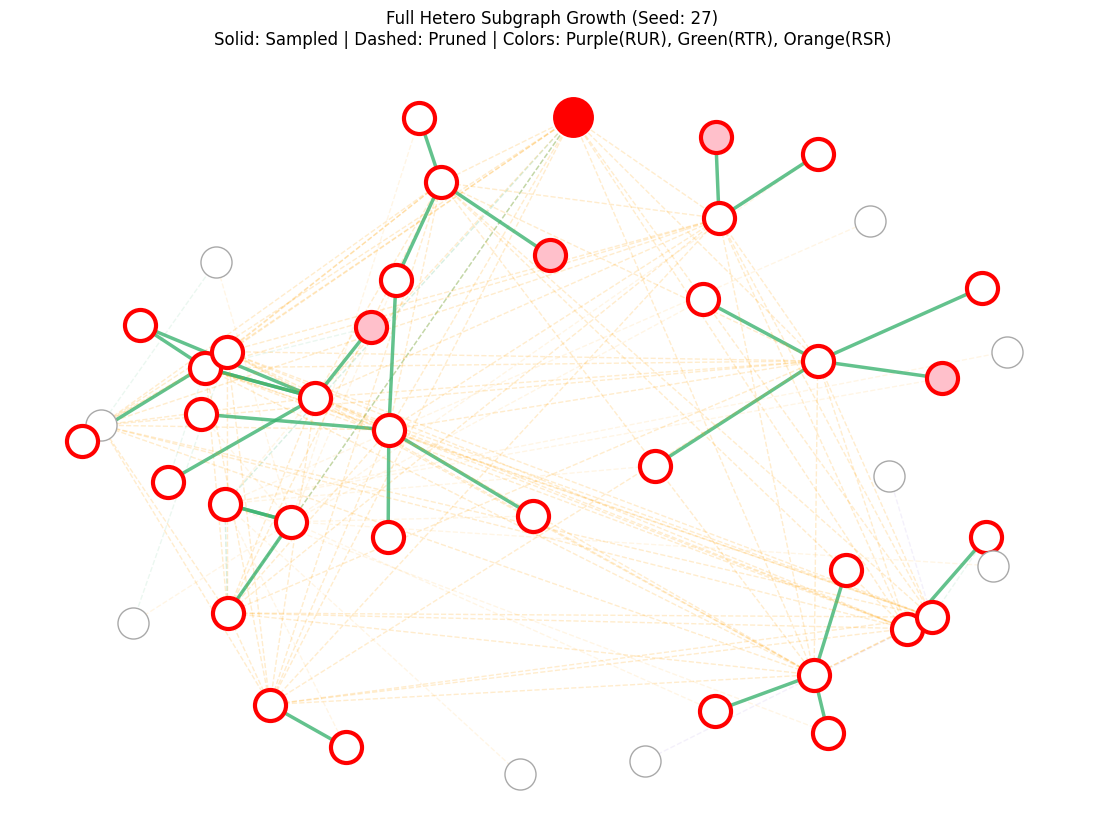

In [44]:
visualize_full_hetero_growth(27)

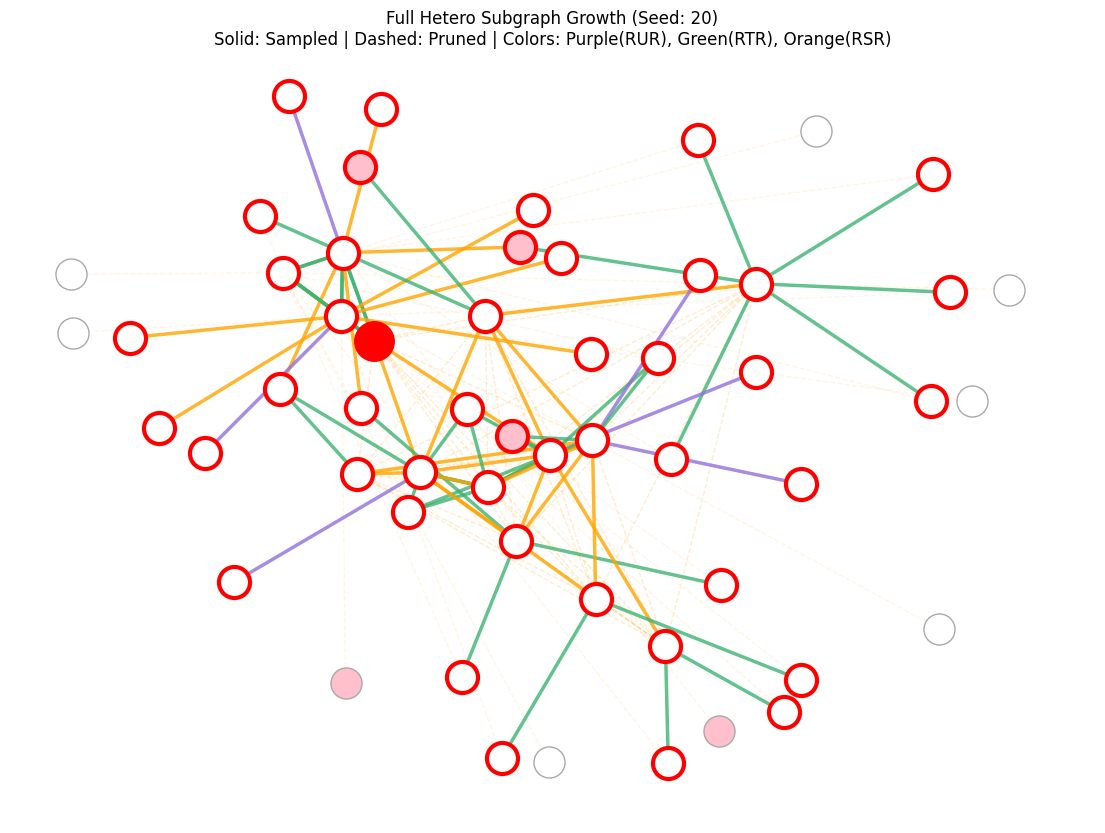

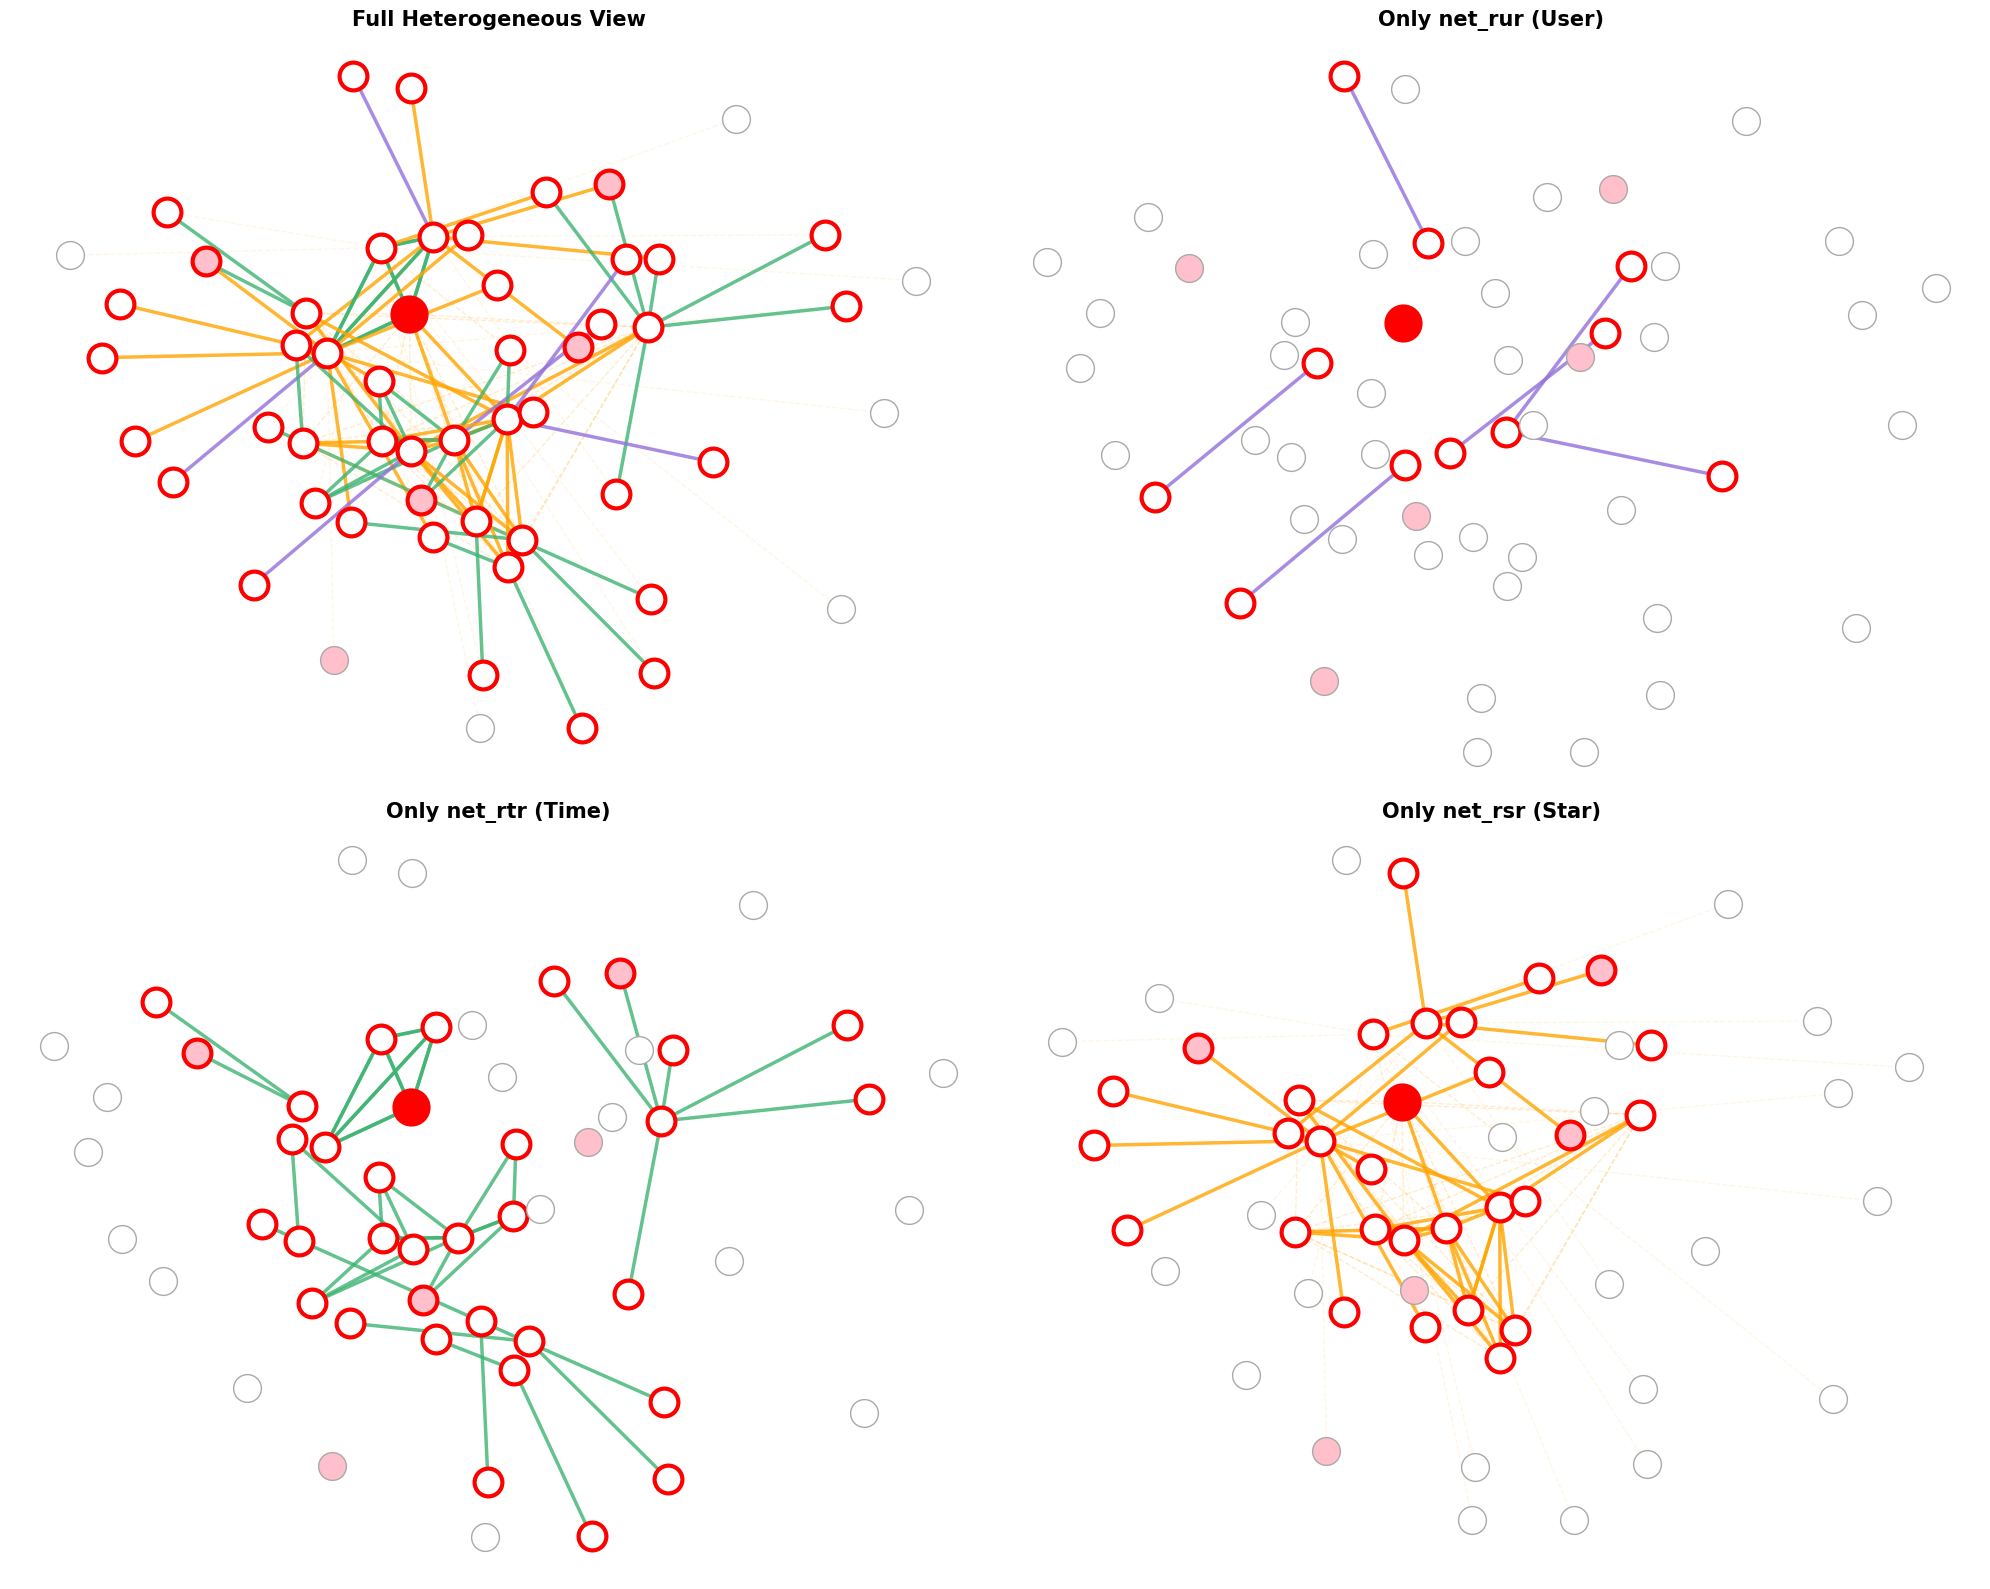

In [ ]:

visualize_full_hetero_growth(20)

visualize_hetero_comparison_optimized()